# Prediction Model File

This file will utilize the insurance_data_cleaned.csv file to conduct prediction model. The goal is to compare different prediction models, and understand the most practical prediction model that could balance both interpretability and prediction accuracy.

## Reading in data & correlation plot

As the first step, we would investigate the scatterplot pairs across all variables within the data files, to see if there is any obvious trends and relationship between different variables. 

In [18]:
# Loading all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, log_loss, roc_auc_score, 
                             roc_curve, precision_recall_curve, confusion_matrix, 
                             accuracy_score, classification_report)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Importing warnings, suppresing all warnings
import warnings
warnings.filterwarnings('ignore')

# Setting the background of the plots to white
sns.set_style('whitegrid')

In [19]:
# Read in data 
df = pd.read_csv('insurance_data_cleaned.csv')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185560 entries, 0 to 185559
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CHANNEL1                   185560 non-null  int64  
 1   CHANNEL2                   185560 non-null  int64  
 2   CHANNEL3                   185560 non-null  int64  
 3   ENTRY AGE                  185560 non-null  int64  
 4   SEX                        185560 non-null  str    
 5   POLICY TYPE 1              185560 non-null  int64  
 6   POLICY TYPE 2              185560 non-null  int64  
 7   POLICY TYPE 3              185560 non-null  str    
 8   PAYMENT MODE               185560 non-null  str    
 9   POLICY STATUS              185560 non-null  str    
 10  BENEFIT                    185560 non-null  float64
 11  NON LAPSE GUARANTEED       185560 non-null  str    
 12  SUBSTANDARD RISK           185560 non-null  float64
 13  NUMBER OF ADVANCE PREMIUM  185560 non-nu

### Checking with scatterplot between different variables available in the dataset

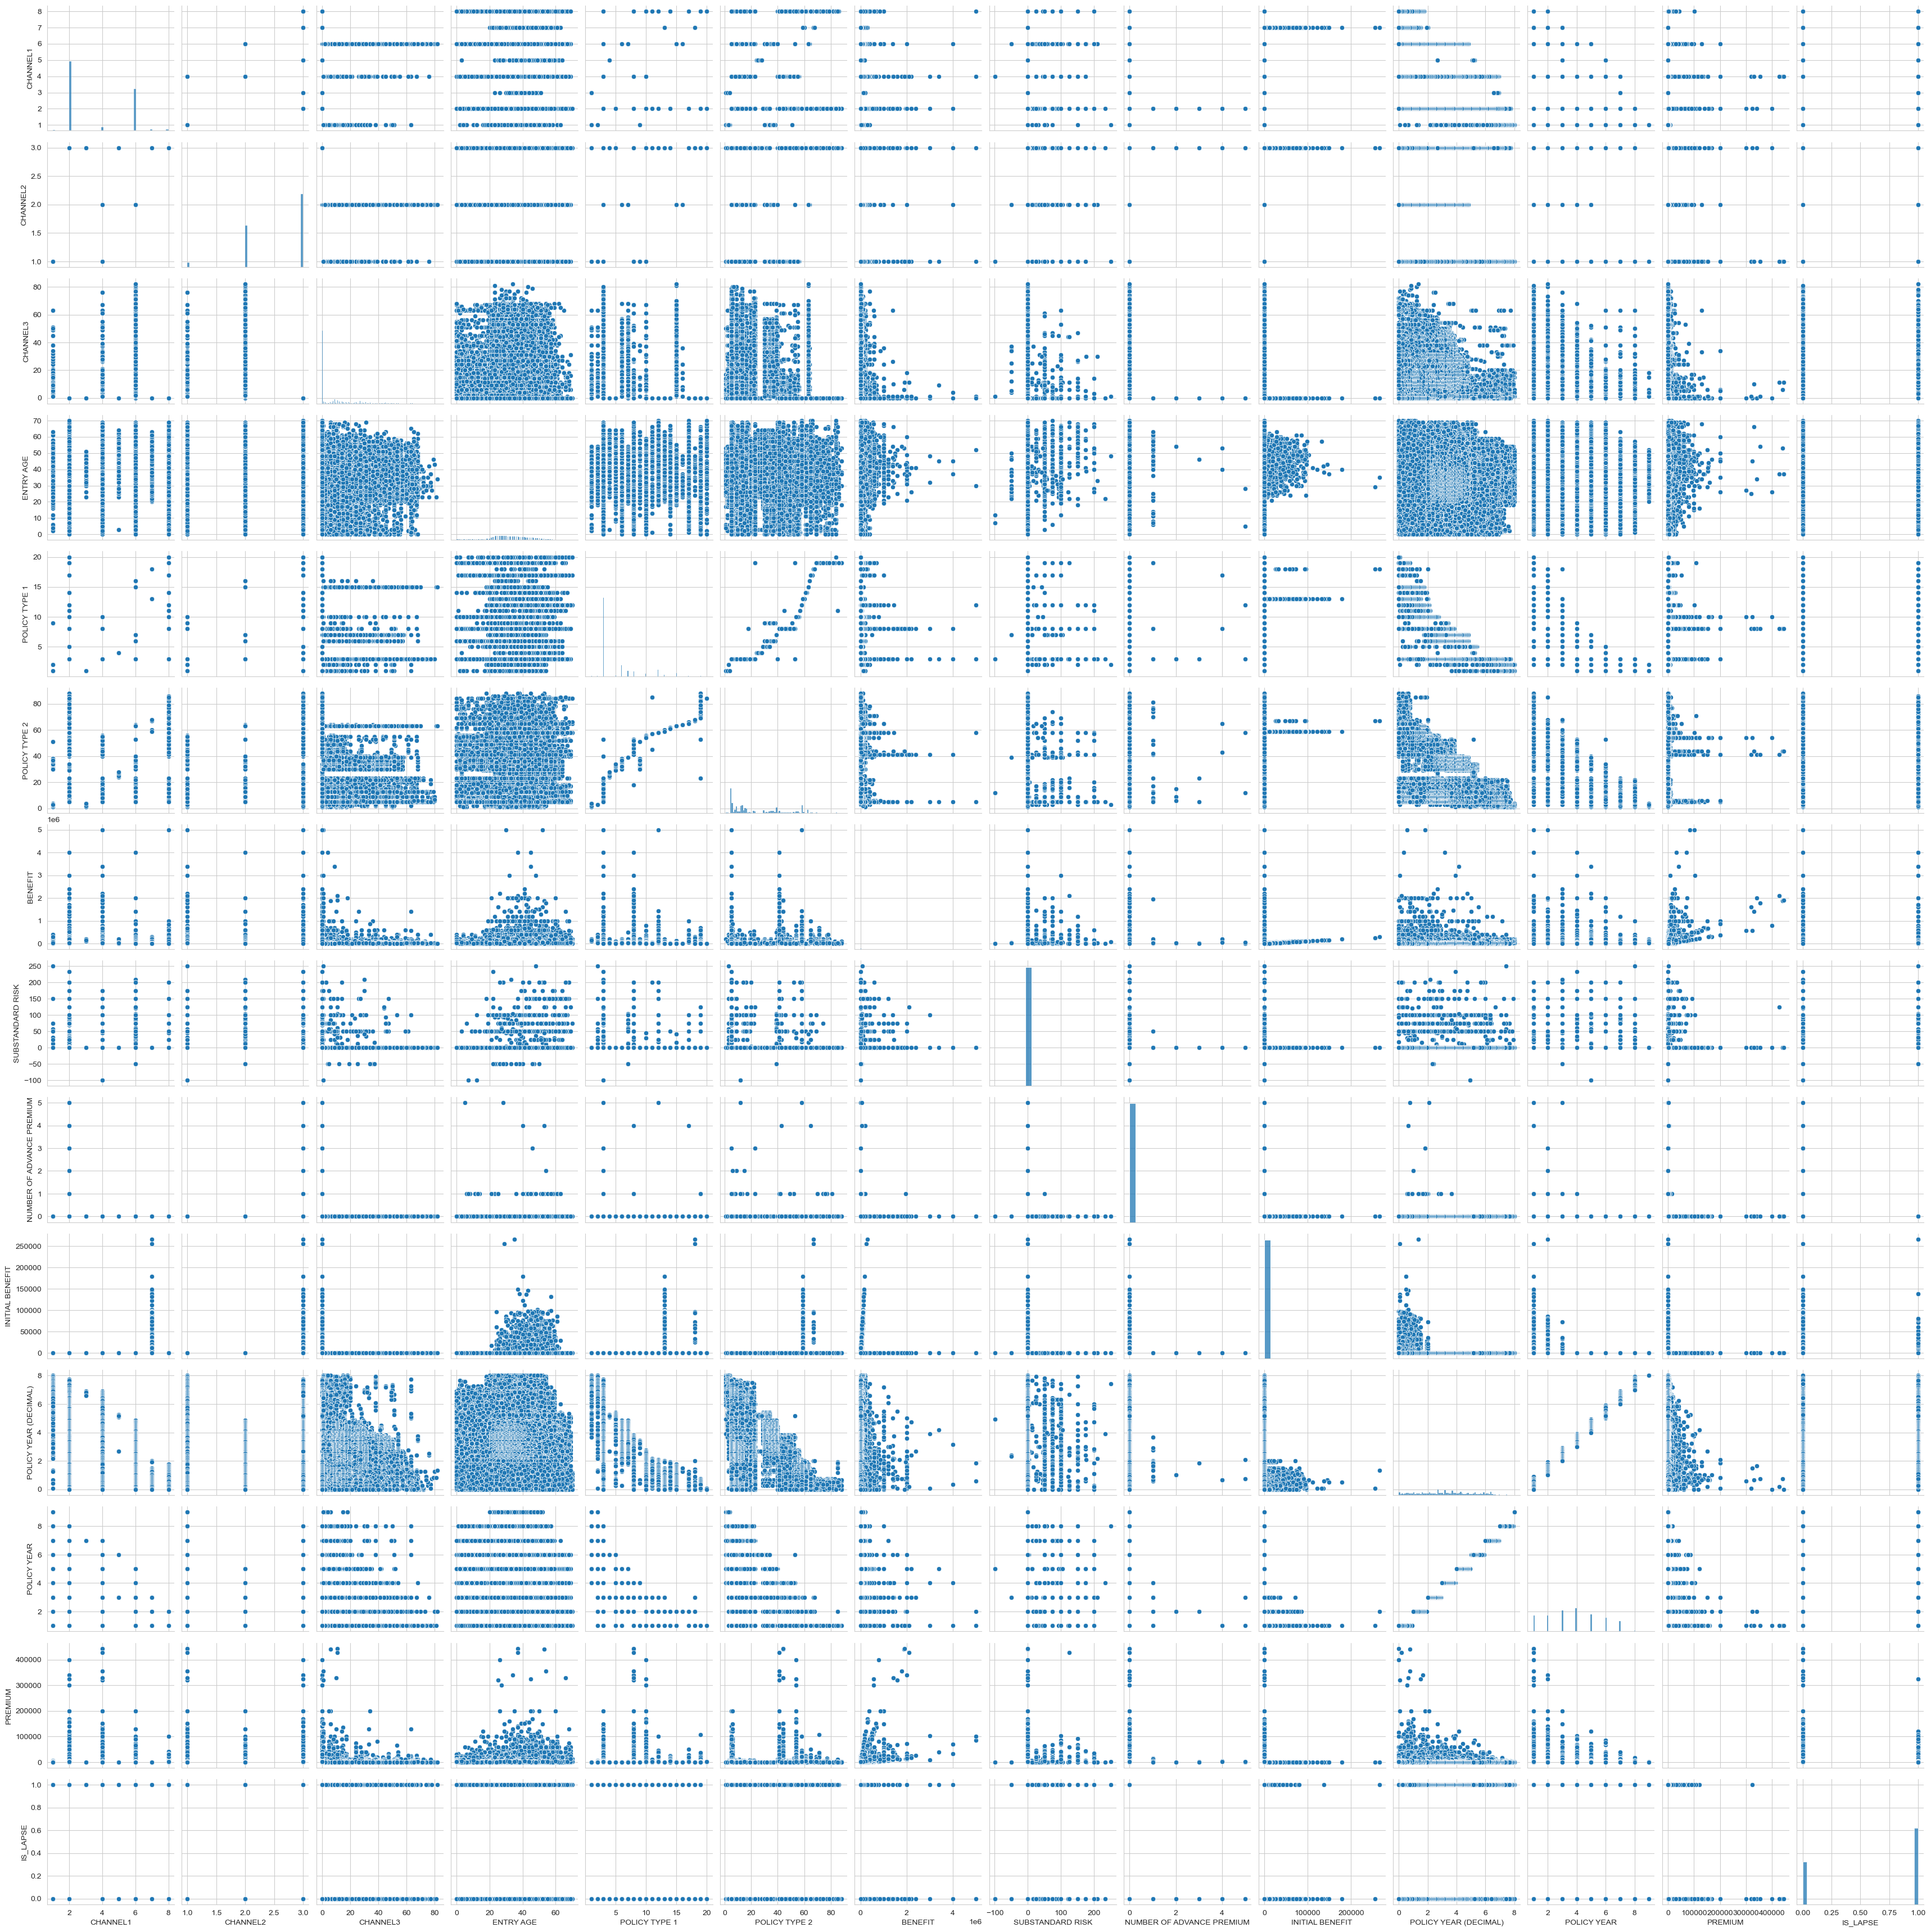

In [57]:
# Create a pairs scatterplot to visualize relationships between numeric features and the target

# 1. Use pairplot on the whole dataframe
# Python will automatically only plot the numeric columns (floats/ints)
sns.pairplot(df)

# 2. Display
plt.show()

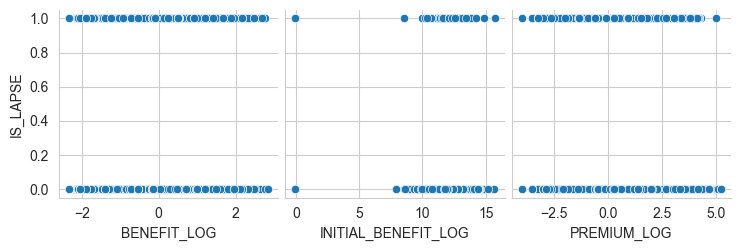

In [21]:
# Based on the pairplot about, we can see that there is an inverted sigmoid relationship
# Between lapse rate and BENEFIT, INITIAL BENEFIT, PREMIUM
# This will be important for prediction using logistics regression

# 1. Log Transform (handles the huge range/skewness)
# Use np.log1p to safely handle 0s (log(0+1) = 0)
df['BENEFIT_LOG'] = np.log1p(df['BENEFIT'])
df['INITIAL_BENEFIT_LOG'] = np.log1p(df['INITIAL BENEFIT'])
df['PREMIUM_LOG'] = np.log1p(df['PREMIUM'])

# 2. Standardization (centers the data around 0)
# Logistic regression math works best when features are on a similar scale
scaler = StandardScaler()
cols_to_scale = ['BENEFIT_LOG', 'INITIAL_BENEFIT_LOG', 'PREMIUM_LOG']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 3. Visualization
sns.pairplot(df, y_vars=['IS_LAPSE'], x_vars=cols_to_scale)
plt.show()

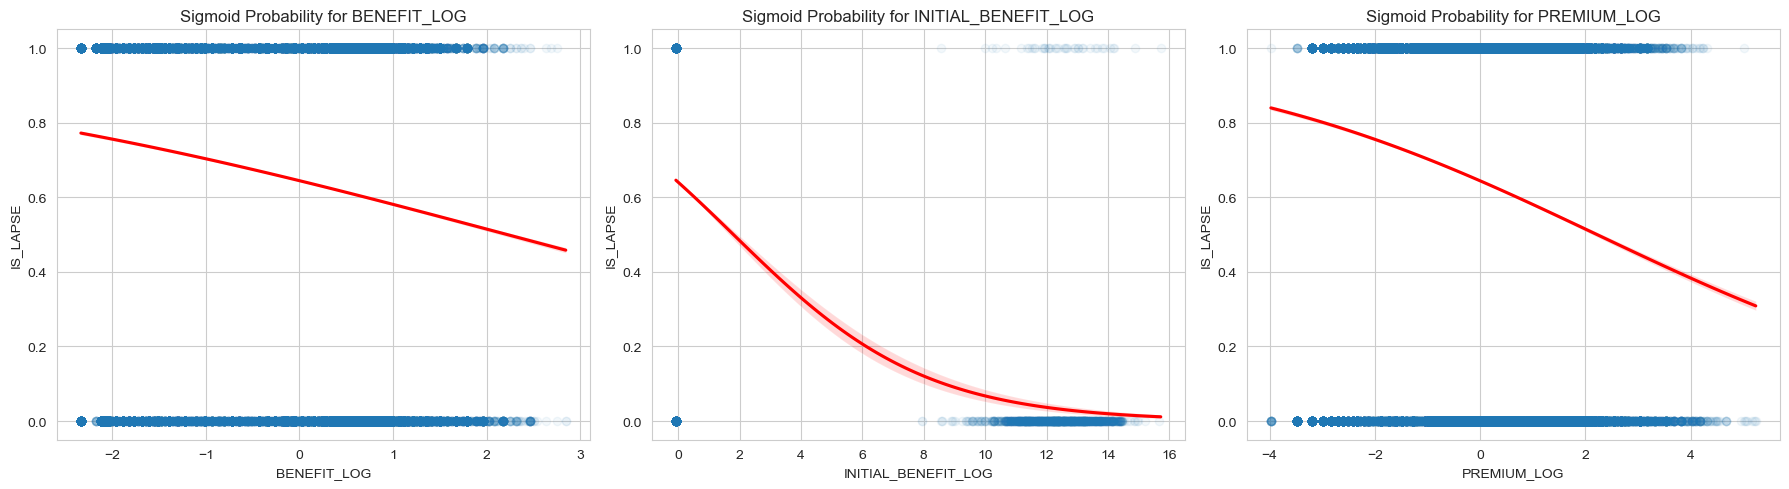

In [25]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['BENEFIT_LOG', 'INITIAL_BENEFIT_LOG', 'PREMIUM_LOG']

for i, col in enumerate(features):
    # sns.regplot with logistic=True will draw the actual S-curve
    # n_boot=100 speeds it up since you have a large dataset
    sns.regplot(x=col, y='IS_LAPSE', data=df, 
                logistic=True, ax=axes[i], 
                scatter_kws={'alpha':0.05}, # Makes dots transparent so you see density
                line_kws={'color':'red'})   # Highlights the Sigmoid curve
    axes[i].set_title(f'Sigmoid Probability for {col}')

plt.tight_layout()
plt.show()

In [22]:
# The sigmoid curves confirm the inverted S-shape relationship between the log-transformed features and the probability of lapse.
# However, the sigmoid is still inverted.
# Let's try inverting my response variable
df['IS_LAPSE_INVERTED'] = 1 - df['IS_LAPSE']

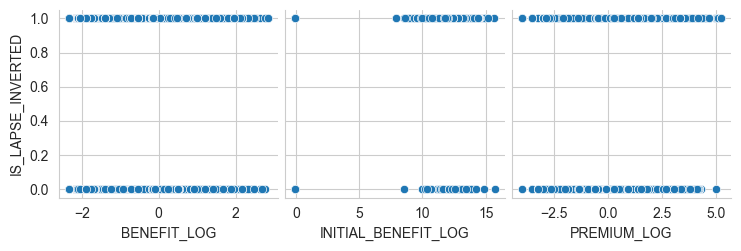

In [23]:
# Plotting the sigmoid curves again with the inverted response variable
scaler = StandardScaler()
cols_to_scale = ['BENEFIT_LOG', 'INITIAL_BENEFIT_LOG', 'PREMIUM_LOG']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 3. Visualization
sns.pairplot(df, y_vars=['IS_LAPSE_INVERTED'], x_vars=cols_to_scale)
plt.show()

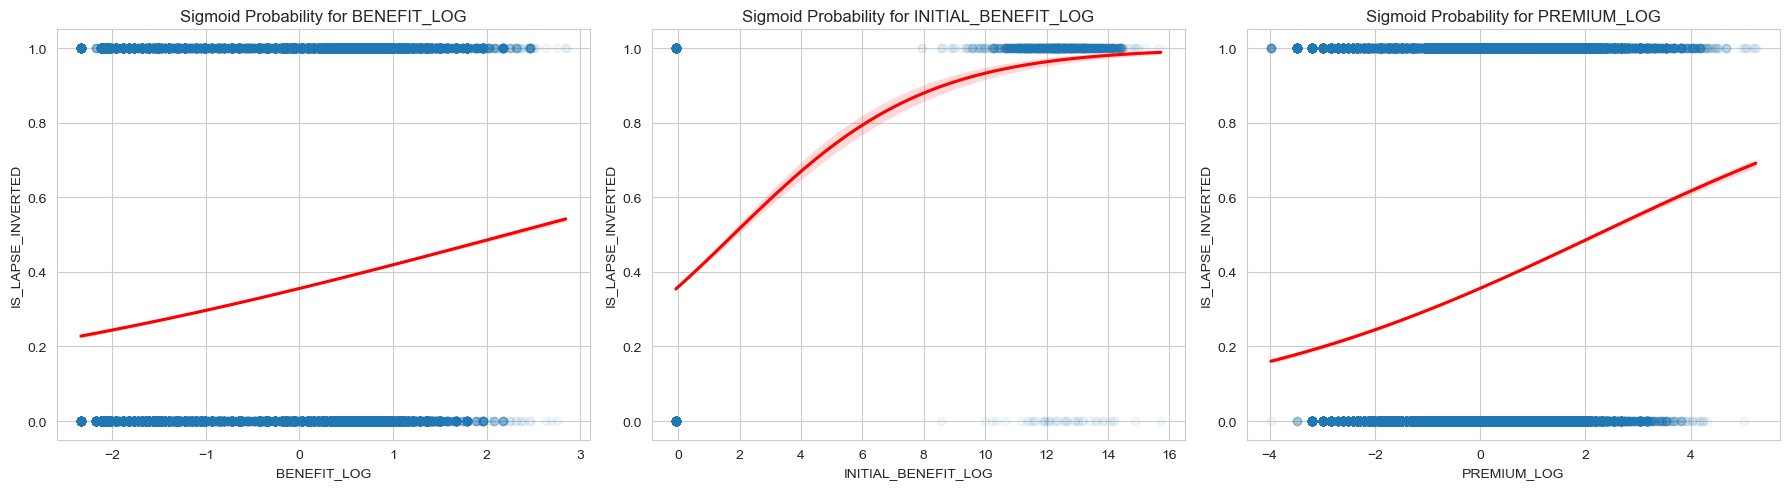

In [28]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['BENEFIT_LOG', 'INITIAL_BENEFIT_LOG', 'PREMIUM_LOG']

for i, col in enumerate(features):
    # sns.regplot with logistic=True will draw the actual S-curve
    # n_boot=100 speeds it up since you have a large dataset
    sns.regplot(x=col, y='IS_LAPSE_INVERTED', data=df, 
                logistic=True, ax=axes[i], 
                scatter_kws={'alpha':0.05}, # Makes dots transparent so you see density
                line_kws={'color':'red'})   # Highlights the Sigmoid curve
    axes[i].set_title(f'Sigmoid Probability for {col}')

plt.tight_layout()
plt.show()

By inverting the response variable, the relationship has turned into a sigmoid shape, which will help logistic regressions in learning the pattern and predicting the relationship better. 

From now onwards, we will redefine our response variable. 

CONTINUE: 0 = DO NOT CONTINUE/LAPSE; 1 = CONTINUE

In [24]:
# Drop the temporary inverted column
df.drop(columns=['IS_LAPSE_INVERTED'], inplace=True) 

# Transform the response variable
df['CONTINUE'] = 1 - df['IS_LAPSE']
df.drop(columns=['IS_LAPSE'], inplace=True)

To make our life easier, we will drop the log variables first. 
However, we will need to add them back when we are training logistics regression or distance-based models (eg KNN, Neural Network). 

In [25]:
# Two different data frame, one with log, one without
df.drop(columns=['BENEFIT_LOG', 'INITIAL_BENEFIT_LOG', 'PREMIUM_LOG'], inplace=True)

### Processing data
Based on the plot above, we can see that there is a strong linear correlation between POLICY YEAR and POLICY YEAR (DECIMAL). We will drop the POLICY YEAR since it has the same information as the POLICY YEAR (DECIMAL), and including them will cause multicollinearity problem. 

We will also drop other variables which are not relevant to our analysis/cannot provide additional information to our prediction model. 

Since there is negative values for substandard risk, which is invalid values for risk, we will also drop those values.

In [26]:
# Dropping irrelevant columns
col_drop = ['POLICY STATUS', 'POLICY YEAR','ISSUE DATE']
df = df.drop(columns=col_drop)

In [27]:
# Dropping rows with substandard risk <0 
df = df.drop(df[df['SUBSTANDARD RISK'] < 0].index)

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 185537 entries, 0 to 185559
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CHANNEL1                   185537 non-null  int64  
 1   CHANNEL2                   185537 non-null  int64  
 2   CHANNEL3                   185537 non-null  int64  
 3   ENTRY AGE                  185537 non-null  int64  
 4   SEX                        185537 non-null  str    
 5   POLICY TYPE 1              185537 non-null  int64  
 6   POLICY TYPE 2              185537 non-null  int64  
 7   POLICY TYPE 3              185537 non-null  str    
 8   PAYMENT MODE               185537 non-null  str    
 9   BENEFIT                    185537 non-null  float64
 10  NON LAPSE GUARANTEED       185537 non-null  str    
 11  SUBSTANDARD RISK           185537 non-null  float64
 12  NUMBER OF ADVANCE PREMIUM  185537 non-null  int64  
 13  INITIAL BENEFIT            185537 non-null  f

In [29]:
# Converting string variables to categorical variables (using dummies)
# Select Features (Defining Continuous vs Categorical for Box-Tidwell later)
continuous_features = ['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 
                       'ENTRY AGE', 'POLICY TYPE 1', 'POLICY TYPE 2', 'SUBSTANDARD RISK',
                       'PREMIUM', 'BENEFIT', 'POLICY YEAR (DECIMAL)', 'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT']
categorical_features = ['SEX', 'PAYMENT MODE','POLICY TYPE 3','NON LAPSE GUARANTEED', 'FULL BENEFIT?']

# 3. Handle Dummies (drop_first=True to avoid multicollinearity)
X = pd.get_dummies(df[continuous_features + categorical_features], drop_first=True).astype(float)

# Transform the response variable
#df['CONTINUE'] = 1 - df['IS_LAPSE']
#df.drop(columns=['IS_LAPSE'], inplace=True)

y = df['CONTINUE']

In [30]:
# Check the structure of feature set
X.info()

<class 'pandas.DataFrame'>
Index: 185537 entries, 0 to 185559
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   CHANNEL1                             185537 non-null  float64
 1   CHANNEL2                             185537 non-null  float64
 2   CHANNEL3                             185537 non-null  float64
 3   ENTRY AGE                            185537 non-null  float64
 4   POLICY TYPE 1                        185537 non-null  float64
 5   POLICY TYPE 2                        185537 non-null  float64
 6   SUBSTANDARD RISK                     185537 non-null  float64
 7   PREMIUM                              185537 non-null  float64
 8   BENEFIT                              185537 non-null  float64
 9   POLICY YEAR (DECIMAL)                185537 non-null  float64
 10  NUMBER OF ADVANCE PREMIUM            185537 non-null  float64
 11  INITIAL BENEFIT              

### Data splitting

After we have complete some basic data processing, we move forward with splitting the data. We will first

(1) Split the data into training and testing set according to 85-15 ratio. The training set is used to train the model, whereas the testing set acts as unseen and unknown data, useful for our to test the out of sample performance of our model to ensure a more robust analysis. 

(2) Then, we will further split the training set into training and validation set, according to a 70-30 ratio. The training set is used to train the model, whereas the validation set is used to test the current model performance, assuming that the training set is the data we collected. 

In [31]:
# Splitting data
# First split: Separate the "Unseen" Test Set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Second split: Split the remaining 85% into Train (70%) and Validation (30%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.30, random_state=42, stratify=y_temp)

print(f"Data Split Complete:\nTrain: {X_train.shape[0]}\nVal: {X_val.shape[0]}\nTest: {X_test.shape[0]}")

Data Split Complete:
Train: 110394
Val: 47312
Test: 27831


### Checking Multicollinearity

Right now we have finished splitting the data. We will enter the next stage which is checking multicollinearity using Variance Inflation Factor (VIF). This method aims to discover any closely related variables, which might inflate the variance of our coefficients and make them unstable. Ideally, we hope our features are very uncorrelated betweene each other so each of them could provide unique and distinct information to predicting responses.

In [32]:
# We check this on the training set to avoid data leakage
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    # Add constant for VIF calculation
    X_vif = sm.add_constant(X_df)
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X_df.columns))]
    return vif_data

print("\n--- Variance Inflation Factor (VIF) ---")
print(calculate_vif(X_train))


--- Variance Inflation Factor (VIF) ---
                                Feature        VIF
0                              CHANNEL1   3.718692
1                              CHANNEL2   2.679632
2                              CHANNEL3   2.093053
3                             ENTRY AGE   1.040134
4                         POLICY TYPE 1  12.354155
5                         POLICY TYPE 2  11.381739
6                      SUBSTANDARD RISK   1.013375
7                               PREMIUM   1.297758
8                               BENEFIT   1.338680
9                 POLICY YEAR (DECIMAL)   1.682636
10            NUMBER OF ADVANCE PREMIUM   1.003361
11                      INITIAL BENEFIT   1.427098
12                                SEX_M   1.019880
13                 PAYMENT MODE_Monthly   1.692614
14                PAYMENT MODE_Quaterly   1.369073
15            PAYMENT MODE_Semiannually   1.188937
16          PAYMENT MODE_Single Premium   2.095477
17                      POLICY TYPE 3_B  

Criteria for VIF evaluation:

* VIF = 1: Not correlated.
* VIF 1–5: Moderately correlated.
* VIF > 10: Serious multicollinearity, requires correction

Based on the results above, we saw a large VIF for POLICY TYPE 1 and 2, indicating that there is a strong correlation between these two variables, and they likely contribute the same information to predicting the response. Since that's the case, we will drop POLICY TYPE 2. 

In addition, there is a high correlation between 2 levels, SUSPEND and NO NLG in the NON LAPSE GUARANTEED categories, indicating that both levels might be conveying the same information. Since they are both technically 'Inactive', we could group them under one categories - Inactive.

In [33]:
# Create the new 'Inactive' column by adding the two columns together
# (Since a row can only be one or the other, the sum will be 1 or 0)
for i in [X_train, X_val, X_test]:  
    i['NON LAPSE GUARANTEED_Inactive'] = i['NON LAPSE GUARANTEED_NLG Not Active'] + i['NON LAPSE GUARANTEED_NO NLG'] + i['NON LAPSE GUARANTEED_NLG Suspend']

    # Now drop the old redundant columns and Policy Type 2
    cols_to_remove = [
        'NON LAPSE GUARANTEED_NLG Not Active',
        'NON LAPSE GUARANTEED_NO NLG', 
        'NON LAPSE GUARANTEED_NLG Suspend', 
        'POLICY TYPE 2'
    ]

    i.drop(columns=cols_to_remove, inplace=True)

In [22]:
# Check VIF again after creating the new 'Inactive' column and dropping the old ones
print("\n--- Variance Inflation Factor (VIF) ---")
print(calculate_vif(X_train))


--- Variance Inflation Factor (VIF) ---
                          Feature       VIF
0                        CHANNEL1  3.698844
1                        CHANNEL2  2.676044
2                        CHANNEL3  2.092345
3                       ENTRY AGE  1.039110
4                   POLICY TYPE 1  1.727605
5                SUBSTANDARD RISK  1.013334
6                         PREMIUM  1.297349
7                         BENEFIT  1.338178
8           POLICY YEAR (DECIMAL)  1.666447
9       NUMBER OF ADVANCE PREMIUM  1.003178
10                INITIAL BENEFIT  1.426966
11                          SEX_M  1.019796
12           PAYMENT MODE_Monthly  1.674164
13          PAYMENT MODE_Quaterly  1.362629
14      PAYMENT MODE_Semiannually  1.187923
15    PAYMENT MODE_Single Premium  2.086174
16                POLICY TYPE 3_B  1.376234
17                POLICY TYPE 3_C  1.491861
18                POLICY TYPE 3_D  1.222646
19                POLICY TYPE 3_E  1.306500
20                FULL BENEFIT?_Y  

In [34]:
continuous_features = ['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 
                       'ENTRY AGE', 'POLICY TYPE 1', 'SUBSTANDARD RISK',
                       'PREMIUM', 'BENEFIT', 'POLICY YEAR (DECIMAL)', 'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT']
categorical_features = ['SEX', 'PAYMENT MODE','POLICY TYPE 3','NON LAPSE GUARANTEED', 'FULL BENEFIT?']


## Logistics Regression

Before conducting logistic regression, we will first check the assumptions, which includes

(1) Binary Outcome (target is 0/1)
(2) Independence of errors: Assumed (unless policies are from the same household/group)
(3) Linearity of independent variables and log-odds: Check this via Box-Tidwell.

In [35]:
# Assumption checks for Assumption 1
y_train.value_counts(normalize=True)
# Yes, the first assumption is fulfilled.

CONTINUE
0    0.641828
1    0.358172
Name: proportion, dtype: float64

In [36]:
# Assumption checks for Assumption 3 - Box-Tidwell Test for Linearity of Logit

# Box-Tidwell checks if the relationship between continuous features and log-odds is linear
# This removes dummy variables which are often the cause of 'Singular Matrix'
X_bt_simple = X_train[continuous_features].copy()

for col in continuous_features:
    # Use a slightly larger constant if you have small values
    X_bt_simple[f'{col}_log'] = X_bt_simple[col] * np.log(X_bt_simple[col] + 1)

# 2. Add constant
X_bt_simple = sm.add_constant(X_bt_simple)

# 3. Fit ONLY these
try:
    bt_results = sm.Logit(y_train, X_bt_simple).fit(disp=0)
    print(bt_results.summary2().tables[1])

except Exception as e:
    print(f"Error: {e}")
    # If it still fails, check for constant columns
    print("\nColumn Variances (Should not be 0):")
    print(X_bt_simple.var())

                                      Coef.      Std.Err.          z  \
const                          2.572172e+00  2.602653e-01   9.882884   
CHANNEL1                       1.860900e+00  1.580314e-01  11.775505   
CHANNEL2                      -4.609858e+00  3.415487e-01 -13.496930   
CHANNEL3                      -5.237513e-03  8.457960e-03  -0.619241   
ENTRY AGE                     -1.915924e-01  6.370746e-03 -30.073781   
POLICY TYPE 1                  1.853799e-01  2.785908e-02   6.654201   
SUBSTANDARD RISK               4.832547e-03  1.514101e-02   0.319169   
PREMIUM                        2.236830e-04  1.831081e-05  12.215899   
BENEFIT                        3.914538e-06  2.118849e-06   1.847483   
POLICY YEAR (DECIMAL)         -1.826177e+00  3.148188e-02 -58.007232   
NUMBER OF ADVANCE PREMIUM      3.075209e+01  9.778932e+04   0.000314   
INITIAL BENEFIT                5.173831e-04  7.207862e-05   7.178039   
CHANNEL1_log                  -7.085666e-01  6.301642e-02 -11.24

In [37]:
bt_results.pvalues

const                             4.939036e-23
CHANNEL1                          5.220348e-32
CHANNEL2                          1.630302e-41
CHANNEL3                          5.357578e-01
ENTRY AGE                        1.067319e-198
POLICY TYPE 1                     2.848439e-11
SUBSTANDARD RISK                  7.495981e-01
PREMIUM                           2.556597e-34
BENEFIT                           6.467717e-02
POLICY YEAR (DECIMAL)             0.000000e+00
NUMBER OF ADVANCE PREMIUM         9.997491e-01
INITIAL BENEFIT                   7.071831e-13
CHANNEL1_log                      2.474464e-29
CHANNEL2_log                      2.627014e-40
CHANNEL3_log                      3.973045e-01
ENTRY AGE_log                    8.864672e-212
POLICY TYPE 1_log                 2.557913e-08
SUBSTANDARD RISK_log              8.557623e-01
PREMIUM_log                       1.372743e-32
BENEFIT_log                       2.416965e-01
POLICY YEAR (DECIMAL)_log         0.000000e+00
NUMBER OF ADV

We conduct Box-Tidwell test, with the null hypothesis H0 of linear relationships between the continuous features and the log-odds. 

Box-Tidwell test the linearity between the predictors and the response variable by adding an interaction term xlogx (represented by VARIABLENAME_log) into the model. If the original relationship is already linear, the model won't "need" this new interaction term to explain the data, and the p-value will be not significant.

Based on the result above, the p-values of most of the log variables is very small (significant), providing sufficient evidence that most of the features and log-odds are not linearly related. 

The insignificant/linearly related variables with response is CHANNEL3, SUBSTANDARD RISK, BENEFIT, NUMBER OF ADVANCE PREMIUM.

Note that in Box-Tidwell test, the p-value of the predictor themselves have no meaningful interpretation, but the interaction term has.

Even though this violates logistic regression, we can still conduct this test as our basic baseline to see the performance. 

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 185537 entries, 0 to 185559
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CHANNEL1                   185537 non-null  int64  
 1   CHANNEL2                   185537 non-null  int64  
 2   CHANNEL3                   185537 non-null  int64  
 3   ENTRY AGE                  185537 non-null  int64  
 4   SEX                        185537 non-null  str    
 5   POLICY TYPE 1              185537 non-null  int64  
 6   POLICY TYPE 2              185537 non-null  int64  
 7   POLICY TYPE 3              185537 non-null  str    
 8   PAYMENT MODE               185537 non-null  str    
 9   BENEFIT                    185537 non-null  float64
 10  NON LAPSE GUARANTEED       185537 non-null  str    
 11  SUBSTANDARD RISK           185537 non-null  float64
 12  NUMBER OF ADVANCE PREMIUM  185537 non-null  int64  
 13  INITIAL BENEFIT            185537 non-null  f

In [39]:
# Conducting logistic regression and threshold analysis with the log-transformed features

# 1. FEATURE ENGINEERING (LOG TRANSFORMS)
# This is because the plots look more sigmoid shape when we log-transform the following continuous variables.
log_features = ['BENEFIT', 'PREMIUM', 'INITIAL BENEFIT']

def apply_log_transform(df_input):
    df_copy = df_input.copy()
    for col in log_features:
        # Create new log columns and drop the raw ones to avoid multicollinearity
        df_copy[f'{col}_LOG'] = np.log1p(df_copy[col])
        df_copy = df_copy.drop(columns=[col])
    return df_copy

X_train_log = apply_log_transform(X_train)
X_val_log = apply_log_transform(X_val)
X_test_log = apply_log_transform(X_test)

# Update the list of continuous features for the scaler
# We replace the old names with the new _LOG names
current_cont_features = [f + '_LOG' if f in log_features else f for f in continuous_features]

# 2. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_log.copy()
X_val_scaled = X_val_log.copy()
X_test_scaled = X_test_log.copy()

X_train_scaled[current_cont_features] = scaler.fit_transform(X_train_log[current_cont_features])
X_val_scaled[current_cont_features] = scaler.transform(X_val_log[current_cont_features])
X_test_scaled[current_cont_features] = scaler.transform(X_test_log[current_cont_features])


# 3. FIT LOGISTIC REGRESSION
X_train_final = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_final).fit(maxiter=1000, disp=0)

# Generate Probabilities
y_prob_val = logit_model.predict(sm.add_constant(X_val_scaled))
y_prob_test = logit_model.predict(sm.add_constant(X_test_scaled))

In [27]:
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:               CONTINUE   No. Observations:               110394
Model:                          Logit   Df Residuals:                   110371
Method:                           MLE   Df Model:                           22
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  0.1715
Time:                        16:09:55   Log-Likelihood:                -59668.
converged:                      False   LL-Null:                       -72017.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             0.0045    938.944   4.77e-06      1.000   -1840.292    1840.301
CHANNEL1                          0.0269      0.014      1.930      0.054 

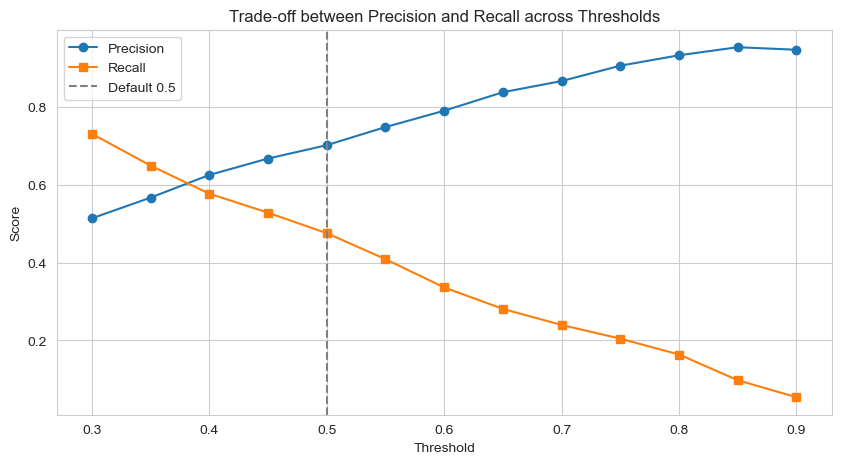

In [69]:
# 4. THRESHOLD ANALYSIS (Precision vs Recall)

# Setting up different thresholds
thresholds = np.arange(0.3, 0.95, 0.05)
precision_list = []
recall_list = []
accuracy_list = []

for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    # Using classification_report or manual calculation
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_list.append(prec)
    recall_list.append(rec)
    accuracy_list.append(accuracy_score(y_val, y_pred_t))

# Plot Precision-Recall Tradeoff
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision_list, label='Precision', marker='o')
plt.plot(thresholds, recall_list, label='Recall', marker='s')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5')
plt.title('Trade-off between Precision and Recall across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

In [70]:
# Find the exact intersection point using interpolation
from scipy.interpolate import interp1d

# Create interpolation functions
f_prec = interp1d(thresholds, precision_list, kind='linear')
f_rec = interp1d(thresholds, recall_list, kind='linear')

# Find where the difference is zero
def find_intersection(t):
    return f_prec(t) - f_rec(t)

from scipy.optimize import brentq
exact_threshold = brentq(find_intersection, 0.3, 0.4)

print(f"Exact Interpolated Intersection: {exact_threshold:.4f}")

Exact Interpolated Intersection: 0.3816


1. Precision (Quality)

Precision answers the question: "Of all the instances the model predicted as positive, how many were actually positive?"It is about being accurate and avoiding "False Alarms."

Formula:$$\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$High Precision means: When the model says "Yes," you can usually trust it.

2. Recall (Quantity) = True Positive Rate

Recall (also called Sensitivity) answers the question: "Of all the actual positive instances that exist, how many did the model find?"It is about completeness and not missing anyone.

Formula:$$\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$High Recall means: The model is great at finding all the targets, even if it accidentally catches some "garbage" along with them.

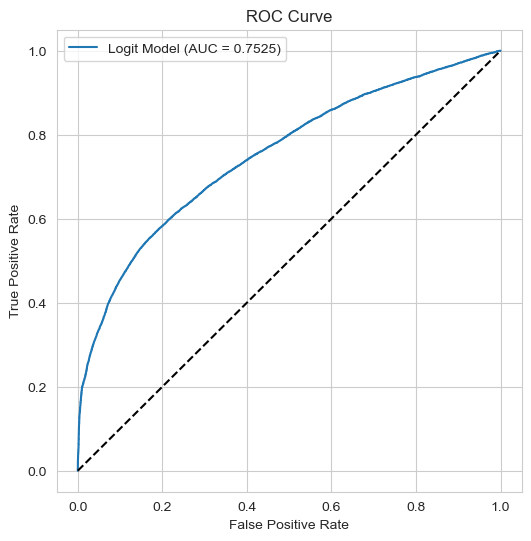

In [71]:
# --- 5. ROC CURVE & AUC ---
fpr, tpr, _ = roc_curve(y_val, y_prob_val)
auc_score = roc_auc_score(y_val, y_prob_val)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logit Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [72]:
# 6. FINAL TEST PREDICTION (Using "Best" Threshold)
y_pred_test = (y_prob_test >= exact_threshold).astype(int)
misclassification_rate = 1 - accuracy_score(y_test, y_pred_test)

print(f"\n--- Final Test Set Results (Threshold {exact_threshold:.4f}) ---")
print(f"Misclassification Error Rate: {misclassification_rate:.4f}")
print(f"Log-Loss:                     {log_loss(y_test, y_prob_test):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


--- Final Test Set Results (Threshold 0.3816) ---
Misclassification Error Rate: 0.2810
Log-Loss:                     0.5393
ROC AUC Score:                0.7599

Confusion Matrix:
[[13899  3964]
 [ 3857  6111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     17863
           1       0.61      0.61      0.61      9968

    accuracy                           0.72     27831
   macro avg       0.69      0.70      0.70     27831
weighted avg       0.72      0.72      0.72     27831



**Result Interpretation**

1. 13,899 (TN): People who actually lapsed, and 23 correctly predicted they would. (Success!)

2. 6,111 (TP): People who continued, and we correctly predicted they would. (Success!)

3. 3,964 (FP): We thought they would Continue, but they actually Lapsed. (This is a missed risk).

4. 3,857 (FN): We thought they would Lapse, but they actually Continued. (This is a false alarm).

Based on the classification report, we can interpret the precision and recall as:

**Class 0 (Lapse)**
- Precision (0.78): When our model says someone will lapse, it is right 78% of the time (TN/TN+FN). This is based on our prediction.
- Recall (0.78): Out of all the people who actually lapsed, we caught 78% of them (TN/TN+FP). This is based on the actual results.

The same overall interpretation applies to when Class 1 (Continue).
Both of them yield a model overall acuracy of 72% (Misclassification rate = 1 - 0.72 = 0.2810).

By using the intersection threshold (Recall and Precision curve), we have forced the model to be equally good at "finding the lapsers" and "being right about the lapsers", within those who lapse and those who do not. 

By using the intersection threshold of 0.3816, we achieved a **balanced model** that identifies 78% of all actual lapses (Recall for Class 0). While this resulted in a slightly higher misclassification error rate (28%) compared to the standard 0.5 threshold, it provides a much higher utility for the business by significantly reducing the number of missed lapse risks.

In [73]:
# Using 0.5 thresholds (Bayes Classifier)
# 6. FINAL TEST PREDICTION (Using 0.5 Threshold, to compare with the "Best" Threshold)
y_pred_test_05 = (y_prob_test >= 0.5).astype(int)
misclassification_rate_05 = 1 - accuracy_score(y_test, y_pred_test_05)

print(f"\n--- Final Test Set Results (Threshold {0.5:.4f}) ---")
print(f"Misclassification Error Rate: {misclassification_rate_05:.4f}")
print(f"Log-Loss:                     {log_loss(y_test, y_prob_test):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_05))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_05))


--- Final Test Set Results (Threshold 0.5000) ---
Misclassification Error Rate: 0.2583
Log-Loss:                     0.5393
ROC AUC Score:                0.7599

Confusion Matrix:
[[15855  2008]
 [ 5180  4788]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.89      0.82     17863
           1       0.70      0.48      0.57      9968

    accuracy                           0.74     27831
   macro avg       0.73      0.68      0.69     27831
weighted avg       0.74      0.74      0.73     27831



Using the 0.5 threshold (Bayes Classifer), we achieve a lower misclassification error rate at 0.2583. We have a higher recall rate for the Lapse group, but a lower precision.

We also tested results using threshold of 0.4 to 0.5 at 0.01 intervals, and the result is marginally different/very similar to the 0.5 threshold. 

In the insurance context, recall rate might be more important than precision rate. Recall rate specifies how many individuals do we manage to catch, whereas precision is specifying out of all the prediction that model flagged, how many is correct. The former is obviously more expensive because catching as many individuals who is likely to lapse as possible help us to craft targeted marketing materials to nudge the individuals stay in the policies to have enough reserves in place. 

0.5 threshold has a higher recall rate, and overall higher accuracy rate as well compared to 0.38, hence we should go for using 0.5 as our threshold. 


### Feature Selection

We suspect we might not need so many variables all at once, and the extra variables might casue additional noise in terms of prediction. We will conduct feature selection using:
1. LASSO
2. Backward Selection (Using AIC, BIC, Adjusted R^2 and Mallow's Cp as information criteria)

In [ ]:
# Conducting LASSO (L1 penalty)
from sklearn.linear_model import LogisticRegression

--- LASSO Final Test Results (Threshold 0.3805) ---
Features used: 22 out of 22
Misclassification Error Rate: 0.2815
ROC AUC Score:                0.7599

Confusion Matrix:
[[13871  3992]
 [ 3842  6126]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     17863
           1       0.61      0.61      0.61      9968

    accuracy                           0.72     27831
   macro avg       0.69      0.70      0.69     27831
weighted avg       0.72      0.72      0.72     27831



In [46]:
from sklearn.linear_model import LogisticRegressionCV

# This will test 10 different values of C and pick the best one via cross-validation
lasso_cv = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best C found: {lasso_cv.C_[0]}")
print(f"Features kept: {np.sum(lasso_cv.coef_ != 0)}")

KeyboardInterrupt: 

In [25]:
# Use the best penalty for logistic regression penalty
best_penalty = lasso_cv.C_[0]
# 1. Fit Lasso Model (C is the inverse of regularization strength; smaller C = more penalty)
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=best_penalty, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# 2. Generate Probabilities
y_prob_val_lasso = lasso_model.predict_proba(X_val_scaled)[:, 1]
y_prob_test_lasso = lasso_model.predict_proba(X_test_scaled)[:, 1]

# 3. Find Precision-Recall Equilibrium Threshold
prec_lasso, rec_lasso, thresholds_lasso = precision_recall_curve(y_val, y_prob_val_lasso)
idx_lasso = np.argmin(np.abs(prec_lasso[:-1] - rec_lasso[:-1]))
best_t_lasso = thresholds_lasso[idx_lasso]

# 4. Final Test Prediction
y_pred_test_lasso = (y_prob_test_lasso >= best_t_lasso).astype(int)

# 5. Performance Metrics
print(f"--- LASSO Final Test Results (Threshold {best_t_lasso:.4f}) ---")
print(f"Features used: {np.sum(lasso_model.coef_ != 0)} out of {X_train_scaled.shape[1]}")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_lasso):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_lasso):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_lasso))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_lasso))

--- LASSO Final Test Results (Threshold 0.3806) ---
Features used: 22 out of 22
Misclassification Error Rate: 0.2814
ROC AUC Score:                0.7599

Confusion Matrix:
[[13873  3990]
 [ 3843  6125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     17863
           1       0.61      0.61      0.61      9968

    accuracy                           0.72     27831
   macro avg       0.69      0.70      0.69     27831
weighted avg       0.72      0.72      0.72     27831



In [36]:
# 4. Final Test Prediction using 0.5 threshold
y_pred_test_lasso = (y_prob_test_lasso >= 0.5158).astype(int)

# 5. Performance Metrics
print(f"--- LASSO Final Test Results (Threshold {0.5158}) ---")
print(f"Features used: {np.sum(lasso_model.coef_ != 0)} out of {X_train_scaled.shape[1]}")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_lasso):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_lasso):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_lasso))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_lasso))

--- LASSO Final Test Results (Threshold 0.5158) ---
Features used: 22 out of 22
Misclassification Error Rate: 0.2574
ROC AUC Score:                0.7599

Confusion Matrix:
[[16069  1794]
 [ 5369  4599]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.90      0.82     17863
           1       0.72      0.46      0.56      9968

    accuracy                           0.74     27831
   macro avg       0.73      0.68      0.69     27831
weighted avg       0.74      0.74      0.73     27831



## Logistics Regression + Ramsey RESET Test
The Regression Specification Error Test (RESET) was originally designed for linear regression. It tests whether non-linear combinations of your independent variables have any power in explaining the response variable.

How it works:
1. Fit the original model: Get the predicted values (or log-odds for logistic regression), denoted as $\hat{y}$.
2. Augment the model: Re-run the regression, but add powers of those predicted values (e.g., $\hat{y}^2, \hat{y}^3$) as new independent variables
3. Statistical Test: Use a Wald test or Likelihood Ratio test to see if the coefficients of these new power terms are significantly different from zero.
4. The Logic: If the powers of the predictions are significant, it means there are non-linear patterns in your data that your current linear model is failing to capture.

In [41]:
# Building the Ramsey RESET Test
# Adapting into logistics regression
from scipy import stats

def logistic_ramsey_reset(X, y, power=2):
    """
    Conducts a Ramsey RESET-style test for Logistic Regression.
    H0: The model is correctly specified (no functional form misspecification).
    Ha: The model is misspecified (missing non-linear terms).
    """
    # 1. Fit the initial Null Model
    X_const = sm.add_constant(X)
    logit_model = sm.Logit(y, X_const).fit(disp=0)
    
    # 2. Get the predicted log-odds (linear predictor)
    # log-odds = X * beta
    y_linear_pred = logit_model.predict(X_const, linear=True)
    
    # 3. Create the Augmented Model features
    # We add y_pred^2, y_pred^3, etc.
    X_augmented = X_const.copy()
    for p in range(2, power + 1):
        X_augmented[f'pred_power_{p}'] = y_linear_pred**p
    
    # 4. Fit the Augmented Model
    logit_augmented = sm.Logit(y, X_augmented).fit(disp=0)
    
    # 5. Likelihood Ratio Test
    # LR Statistic = 2 * (LL_augmented - LL_null)
    lr_stat = 2 * (logit_augmented.llf - logit_model.llf)
    df_diff = power - 1
    p_value = stats.chi2.sf(lr_stat, df_diff)
    
    print("--- Ramsey RESET Test for Logistic Regression ---")
    print(f"Likelihood Ratio Statistic: {lr_stat:.4f}")
    print(f"Degrees of Freedom:        {df_diff}")
    print(f"P-value:                   {p_value:.4f}")
    
    if p_value < 0.05:
        print("\nResult: Reject H0. The model is likely MISSPECIFIED.")
        print("Consider adding interaction terms or polynomial features.")
    else:
        print("\nResult: Fail to reject H0. No evidence of misspecification found.")

# Example Usage:
logistic_ramsey_reset(X_train_scaled, y_train, power=2)

--- Ramsey RESET Test for Logistic Regression ---
Likelihood Ratio Statistic: 539.5159
Degrees of Freedom:        1
P-value:                   0.0000

Result: Reject H0. The model is likely MISSPECIFIED.
Consider adding interaction terms or polynomial features.


Ramsey RESET Test clearly tells us the model is misspecified. However, we still need another test/procedure to tell us which interaction effect/polymonial model to include. 

One of the method is to generate interaction terms for all the variables, and fit in LASSO to see which variables survived.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegressionCV

# 1. Initialize without naming constraints
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

# 2. Fit and Transform using the scaled array
# This creates the interactions (e.g., Column 0 * Column 1)
X_poly_train = poly.fit_transform(X_train_scaled)

# 3. FIX: Get the feature names by passing your list of names HERE
# Make sure len(X_train.columns) exactly matches X_train_scaled.shape[1]
try:
    feature_names_out = poly.get_feature_names_out(X_train.columns)
except ValueError:
    # If the error persists, it means your X_train.columns and X_train_scaled 
    # actually have a different number of features. Let's find out why:
    print(f"DataFrame columns: {len(X_train.columns)}")
    print(f"Scaled array columns: {X_train_scaled.shape[1]}")
    # Fallback: use generic names to at least let the code run
    feature_names_out = poly.get_feature_names_out()

# 4. Run LASSO
lasso_cv_poly = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42)
lasso_cv_poly.fit(X_poly_train, y_train)

# 5. Display Selected
coefs = lasso_cv_poly.coef_[0]
selected_features = feature_names_out[coefs != 0]

print(f"\nKept {len(selected_features)} features out of {len(feature_names_out)}")
print("Selected:", selected_features)

DataFrame columns: 22
Scaled array columns: 22


In [38]:
# Backward Subset Selection

def run_backward_selection_workflow(X_train, y_train, X_val, y_test, X_test, y_val):
    # --- 1. BACKWARD ELIMINATION (AIC) ---
    features = list(X_train.columns)
    print("Starting Backward Elimination...")
    
    while len(features) > 0:
        model = sm.Logit(y_train, X_train[features]).fit(disp=0)
        current_aic = model.aic
        
        worst_feature = None
        best_new_aic = current_aic
        
        for feature in features:
            reduced_features = [f for f in features if f != feature]
            # Fitting reduced model
            m = sm.Logit(y_train, X_train[reduced_features]).fit(disp=0)
            if m.aic < best_new_aic:
                best_new_aic = m.aic
                worst_feature = feature
        
        if worst_feature is not None:
            features.remove(worst_feature)
            print(f"Removed {worst_feature:25} | New AIC: {best_new_aic:.2f}")
        else:
            print("Selection Complete: No further improvement in AIC.")
            break

    # --- 2. FIT FINAL MODEL ON SUBSET ---
    final_features = features
    final_subset_model = sm.Logit(y_train, X_train[final_features]).fit(disp=0)
    
    # --- 3. GENERATE PROBABILITIES ---
    # Note: Using .predict() on statsmodels requires the same column subset
    y_prob_val_sub = final_subset_model.predict(X_val[final_features])
    y_prob_test_sub = final_subset_model.predict(X_test[final_features])

    # --- 4. FIND PRECISION-RECALL EQUILIBRIUM ---
    prec_sub, rec_sub, thresholds_sub = precision_recall_curve(y_val, y_prob_val_sub)
    
    # Finding the point where |Precision - Recall| is minimized
    idx_sub = np.argmin(np.abs(prec_sub[:-1] - rec_sub[:-1]))
    best_t_sub = thresholds_sub[idx_sub]

    # --- 5. FINAL TEST EVALUATION ---
    y_pred_test_sub = (y_prob_test_sub >= best_t_sub).astype(int)

    print("\n" + "="*50)
    print(f"--- BACKWARD SELECTION (AIC) FINAL RESULTS ---")
    print(f"Final Features: {len(final_features)}")
    print(f"Optimal Equilibrium Threshold: {best_t_sub:.4f}")
    print(f"Misclassification Error Rate:  {1 - accuracy_score(y_test, y_pred_test_sub):.4f}")
    print(f"ROC AUC Score:                 {roc_auc_score(y_test, y_prob_test_sub):.4f}")
    print("="*50)
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test_sub))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_test_sub))
    
    return final_subset_model, final_features

# EXECUTION
# Assuming X_train_final, X_val_scaled, X_test_scaled are already prepared
final_model, best_features = run_backward_selection_workflow(
    X_train_final, y_train, 
    sm.add_constant(X_val_scaled), y_test, 
    sm.add_constant(X_test_scaled), y_val
)

Starting Backward Elimination...
Removed const                     | New AIC: 119380.44
Selection Complete: No further improvement in AIC.

--- BACKWARD SELECTION (AIC) FINAL RESULTS ---
Final Features: 22
Optimal Equilibrium Threshold: 0.3806
Misclassification Error Rate:  0.2814
ROC AUC Score:                 0.7599

Confusion Matrix:
[[13870  3993]
 [ 3840  6128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     17863
           1       0.61      0.61      0.61      9968

    accuracy                           0.72     27831
   macro avg       0.69      0.70      0.69     27831
weighted avg       0.72      0.72      0.72     27831



## K-Nearest Neighbour Classification

Apart from trying logistic regression, we will test the predictive accuracy using the conventional classification model - K-nearest neighbour. This method classifies the response according to the nearest neighbours. Due to this classification method, scaling and normalizing the predictors are important to ensure predictive accuracy. 

In [22]:
# Conducting KNN with the same log-transformed and scaled features
# 1. FEATURE ENGINEERING (LOG TRANSFORMS)
# To smoothen out/normalize the Benefit, Premium and Initial Benefit this is highily right-skewed
log_features = ['BENEFIT', 'PREMIUM', 'INITIAL BENEFIT']

X_train_log = apply_log_transform(X_train)
X_val_log = apply_log_transform(X_val)
X_test_log = apply_log_transform(X_test)

# Update the list of continuous features for the scaler
# We replace the old names with the new _LOG names
current_cont_features = [f + '_LOG' if f in log_features else f for f in continuous_features]

# 2. SCALING
scaler = StandardScaler()
X_train_scaled = X_train_log.copy()
X_val_scaled = X_val_log.copy()
X_test_scaled = X_test_log.copy()

X_train_scaled[current_cont_features] = scaler.fit_transform(X_train_log[current_cont_features])
X_val_scaled[current_cont_features] = scaler.transform(X_val_log[current_cont_features])
X_test_scaled[current_cont_features] = scaler.transform(X_test_log[current_cont_features])

We are unsure about the best K, so we will try a few different K values and pick the one with the best validation accuracy. We use GridSearch CV to automate this process. 

GridSearchCV (Grid Search Cross-Validation) acts like a "competition" for different values of $k$. It splits your training data into smaller chunks, tests multiple values of $k$, and tells you which one actually produced the best results.

In [23]:
from sklearn.model_selection import GridSearchCV

# 1. Define the range of K values and weighting schemes to try
# Usually, odd numbers are better for KNN to avoid "tie" votes
param_grid = {
    'n_neighbors': [5, 11, 21, 31, 41, 51, 61, 71, 81, 91, 101],
    'weights': ['uniform', 'distance'] 
    # uniform: every matched neighbor has equal vote
    # distance: closer neighbors have more influence
}

# 2. Initialize the GridSearch
# We use 'roc_auc' as the scoring metric because it's threshold-independent
knn_grid = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),  # Performance booster for large datasets
    param_grid, 
    cv=5,              # 5-fold cross-validation
    scoring='roc_auc', # model ability to distinguiseh between classes across all thresholds
    verbose=1          # printing progress report
)

# 3. Fit it (this will take some time with 185k rows)
knn_grid.fit(X_train_scaled, y_train)

# 4. Show the result
print(f"The best K found was: {knn_grid.best_params_['n_neighbors']}")
print(f"The best weighting was: {knn_grid.best_params_['weights']}")

Fitting 5 folds for each of 22 candidates, totalling 110 fits
The best K found was: 81
The best weighting was: uniform


Based on the model above, we obtain $K=81$ is the best K nearest neighbour to use to fit the model. 

Normally through KNN, it will predict the classification of the response variables based on the majority. Using knn.predict, it automatically applies the best threshold at exactly 0.50.

However, to ensure more robust estimation, we still estimate the probabilities of classifying into either class, and from there figuring out a threshold we can use to categorize the response. 

In [24]:
# 4. Extract the best model and generate probabilities
# Use k=81 here
best_knn = knn_grid.best_estimator_

# KNN generates probabilities based on the fraction of neighbors in each class
y_prob_val_knn = best_knn.predict_proba(X_val_scaled)[:, 1]
y_prob_test_knn = best_knn.predict_proba(X_test_scaled)[:, 1]


# 5. Find the intersection threshold for KNN
# We reuse your logic to find the balance point for KNN
prec_knn, rec_knn, thresholds_knn = precision_recall_curve(y_val, y_prob_val_knn)

# To avoid the 'step' nature of KNN probabilities, we use a similar find-intersection logic
# thresholds_knn is slightly different from our manual np.arange, it's generated by the curve
diff_knn = np.abs(prec_knn[:-1] - rec_knn[:-1])
idx_knn = np.argmin(diff_knn)
best_t_knn = thresholds_knn[idx_knn]

print(f"KNN Intersection Threshold: {best_t_knn:.4f}")

KNN Intersection Threshold: 0.3704


In [25]:
# 6. Final test prediction
y_pred_test_knn = (y_prob_test_knn >= best_t_knn).astype(int)

# 7. Performance Metrics for KNN
print(f"\n--- KNN Final Test Results (Threshold {best_t_knn:.4f}) ---")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_knn):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_knn):.4f}") # how smart is the model

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_knn))


--- KNN Final Test Results (Threshold 0.3704) ---
Misclassification Error Rate: 0.2710
ROC AUC Score:                0.7755

Confusion Matrix:
[[14103  3760]
 [ 3782  6186]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     17863
           1       0.62      0.62      0.62      9968

    accuracy                           0.73     27831
   macro avg       0.71      0.71      0.71     27831
weighted avg       0.73      0.73      0.73     27831



In [ ]:
# 6. Final test prediction
y_pred_test_knn_05 = (y_prob_test_knn >= 0.51).astype(int)

# 7. Performance Metrics for KNN
print(f"\n--- KNN Final Test Results (Threshold {0.51}) ---")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_knn_05):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_knn):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_knn_05))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_knn_05))


--- KNN Final Test Results (Threshold 0.51) ---
Misclassification Error Rate: 0.2518
ROC AUC Score:                0.7755

Confusion Matrix:
[[16359  1504]
 [ 5504  4464]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.92      0.82     17863
           1       0.75      0.45      0.56      9968

    accuracy                           0.75     27831
   macro avg       0.75      0.68      0.69     27831
weighted avg       0.75      0.75      0.73     27831



After testing at 0.01 intervals from 0.40 to 0.60, the misclassification error rate is the smallest for 0.51. 

Under KNN methods, we obtained the similar results as logistic regression. The threshold we obtained is around 0.37 to 0.38. They have the balanced precision and recall rate, but have a higher false positive rate compared to using Bayer classifier threshold 0.5. This suggest a question, does using 0.5 always yield the better results, rather than following the precision-recall curve?

Using the same rationale, failure to detecting the lapse is the most expensive situation in the insurance market. This means that we want to minimize the false positive rate, which is when we predict the individuals to continue the policies, but actually they lapse. We can tolerate larger false negative rate, because they are not actually going to lapse the policies. 

## Random Forest Classifier

Unlike Logistics Regression and KNN, Random Forest Classifer is a tree-based (non-parametric) model that does not require strict assumptions. The method handles multicollinearity and generally less sensitive to outliers than regression models. Random Forest Classifer uses Bagging method. 

Under Bagging, Random Forest creates multiple decision trees, parallely and all at once, by training each one on a random subset of the data (sampled with replacement - Bootstrap Aggregating). The final prediction is the majority vote (for classification) of all these trees. 

In [27]:
# Fitting the data into Random Forest Classifier3
# balanced, handle class imbalance
rf_model = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_val) # 1 or 0
rf_probs = rf_model.predict_proba(X_val)[:, 1] # the probability of each prediction to be 1 (continue)

In [28]:
# By default, Random Forest Classifer does classification based on simple majority vote (threshold > 0.5)
# We want to find the threshold that has the balance between precision and recall

# 1. Generate probabilities on the Validation set
# (Assume rf_model is already trained)
y_prob_val_rf = rf_model.predict_proba(X_val)[:, 1]
y_prob_test_rf = rf_model.predict_proba(X_test)[:, 1]

# 2. Generate the Precision-Recall Curve
prec_rf, rec_rf, thresholds_rf = precision_recall_curve(y_val, y_prob_val_rf)

# 3. Find the intersection threshold
# Find the point where the difference between Precision and Recall is minimal
diff_rf = np.abs(prec_rf[:-1] - rec_rf[:-1])
idx_rf = np.argmin(diff_rf)
best_t_rf = thresholds_rf[idx_rf]

print(f"Random Forest Intersection Threshold: {best_t_rf:.4f}")

Random Forest Intersection Threshold: 0.4160


In [30]:
# Final test prediction
y_pred_test_rf = (y_prob_test_rf >= best_t_rf).astype(int)

#  Performance Metrics for KNN
print(f"\n--- RFC Final Test Results (Threshold {best_t_rf:.4f}) ---")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_rf):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_rf))


--- RFC Final Test Results (Threshold 0.4160) ---
Misclassification Error Rate: 0.2797
ROC AUC Score:                0.7693

Confusion Matrix:
[[13945  3918]
 [ 3866  6102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78     17863
           1       0.61      0.61      0.61      9968

    accuracy                           0.72     27831
   macro avg       0.70      0.70      0.70     27831
weighted avg       0.72      0.72      0.72     27831



In [64]:
# Final test prediction
y_pred_test_rf_05 = (y_prob_test_rf >= 0.5).astype(int)

#  Performance Metrics for KNN
print(f"\n--- RFC Final Test Results (Threshold {0.5}) ---")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_rf_05):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_rf_05))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_rf_05))


--- RFC Final Test Results (Threshold 0.5) ---
Misclassification Error Rate: 0.2662
ROC AUC Score:                0.7693

Confusion Matrix:
[[15029  2834]
 [ 4575  5393]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80     17863
           1       0.66      0.54      0.59      9968

    accuracy                           0.73     27831
   macro avg       0.71      0.69      0.70     27831
weighted avg       0.73      0.73      0.73     27831



## XGBoost

Similar to Random Forest, XGBoost is also a non-parametric method that does not require strict assumptions, such as linearity and scaling. The method handles multicollinearity and generally less sensitive to outliers than regression models. 

XG Boost mainly uses Pruning, which is forming multiple trees, learning from previous errors before forming another classification trees. Specifically, XGBoost uses a backward pruning approach, growing the tree to its maximum depth first and then starts pruning nodes backward from the bottom up if the gain at a specific split does not exceed a certain threshold. This is more computationally efficient and robust against overfitting. 

In [32]:
# Fit the data into XGBoost Model
# Random state = 42: set seed
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
xgb_preds = xgb_model.predict(X_val)
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

In [33]:
# By default, XGBoost does classification based on simple majority vote (threshold > 0.5)
# We want to find the threshold that has the balance between precision and recall

# 1. Generate probabilities on the Validation set
y_prob_val_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_prob_test_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 2. Generate the Precision-Recall Curve
prec_xgb, rec_xgb, thresholds_xgb = precision_recall_curve(y_val, y_prob_val_xgb)

# 3. Find the intersection threshold
# Find the point where the difference between Precision and Recall is minimal
diff_xgb = np.abs(prec_xgb[:-1] - rec_xgb[:-1])
idx_xgb = np.argmin(diff_xgb)
best_t_xgb = thresholds_xgb[idx_xgb]

print(f"Random Forest Intersection Threshold: {best_t_xgb:.4f}")

Random Forest Intersection Threshold: 0.3578


In [ ]:
# Final test prediction
y_pred_test_xgb = (y_prob_test_xgb >= best_t_xgb).astype(int)

#  Performance Metrics for KNN
print(f"\n--- KNN Final Test Results (Threshold {best_t_xgb:.4f}) ---")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_xgb):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_xgb))


--- KNN Final Test Results (Threshold 0.3578) ---
Misclassification Error Rate: 0.2594
ROC AUC Score:                0.7963

Confusion Matrix:
[[14237  3626]
 [ 3594  6374]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80     17863
           1       0.64      0.64      0.64      9968

    accuracy                           0.74     27831
   macro avg       0.72      0.72      0.72     27831
weighted avg       0.74      0.74      0.74     27831



In [52]:
# Final test prediction using 0.5 threshold
# This is by trial and error - trying from 0.49 to 0.51 with 0.05 interval

y_pred_test_xgb_05 = (y_prob_test_xgb >= 0.495).astype(int)

#  Performance Metrics for KNN
print(f"\n--- KNN Final Test Results (Threshold {0.495}) ---")
print(f"Misclassification Error Rate: {1 - accuracy_score(y_test, y_pred_test_xgb_05):.4f}")
print(f"ROC AUC Score:                {roc_auc_score(y_test, y_prob_test_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_xgb_05))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_xgb_05))


--- KNN Final Test Results (Threshold 0.495) ---
Misclassification Error Rate: 0.2399
ROC AUC Score:                0.7963

Confusion Matrix:
[[16324  1539]
 [ 5137  4831]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.91      0.83     17863
           1       0.76      0.48      0.59      9968

    accuracy                           0.76     27831
   macro avg       0.76      0.70      0.71     27831
weighted avg       0.76      0.76      0.74     27831



In [50]:
df.columns

Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'SEX', 'POLICY TYPE 1',
       'POLICY TYPE 2', 'POLICY TYPE 3', 'PAYMENT MODE', 'BENEFIT',
       'NON LAPSE GUARANTEED', 'SUBSTANDARD RISK', 'NUMBER OF ADVANCE PREMIUM',
       'INITIAL BENEFIT', 'FULL BENEFIT?', 'POLICY YEAR (DECIMAL)', 'PREMIUM',
       'CONTINUE'],
      dtype='str')

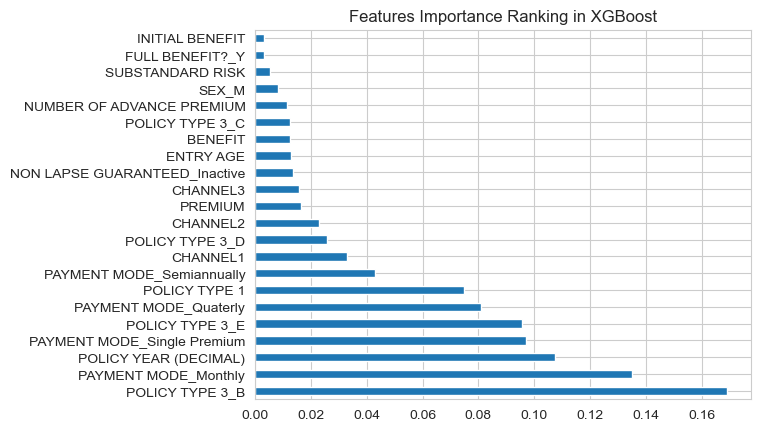

In [53]:
# Feature Importance
# Tree models let you see which variables were most "useful"
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances.nlargest(22).plot(kind='barh', title='Features Importance Ranking in XGBoost')
plt.show()

## LDA, QDA

In this section, we used Linear Discriminant Analysis and Quadratic Discriminant Analysis to do the model prediction. The model will only be performing well if the classes/categories are very sparsely separated, which results in logistic regression under-performing. We will use this classification method to see if we can yield a better performing model, with smaller misclassification rate. 

Because this is a classification problem, we need scaling and normalizing the data. 

There are 4 different assumptions for LDA/QDA, 

1. Normality - each feature should follow a normal distribution within each class. We can check this.

2. Homoscedasticity - in LDA, all classes share the same covariance matrix, if violated, QDA is superior to LDA. We can also check this. 

3. Independence - Observations are independent of each other. We assume the observation collected are independent of each other. 

4. Multicollinearity - Features shouldn't be perfectly correlated. We have check this using VIF method. 

### Assumption Check 

In [49]:
continuous_features = ['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 
                       'ENTRY AGE', 'POLICY TYPE 1', 'SUBSTANDARD RISK',
                       'PREMIUM_LOG', 'BENEFIT_LOG', 'POLICY YEAR (DECIMAL)', 'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT_LOG']

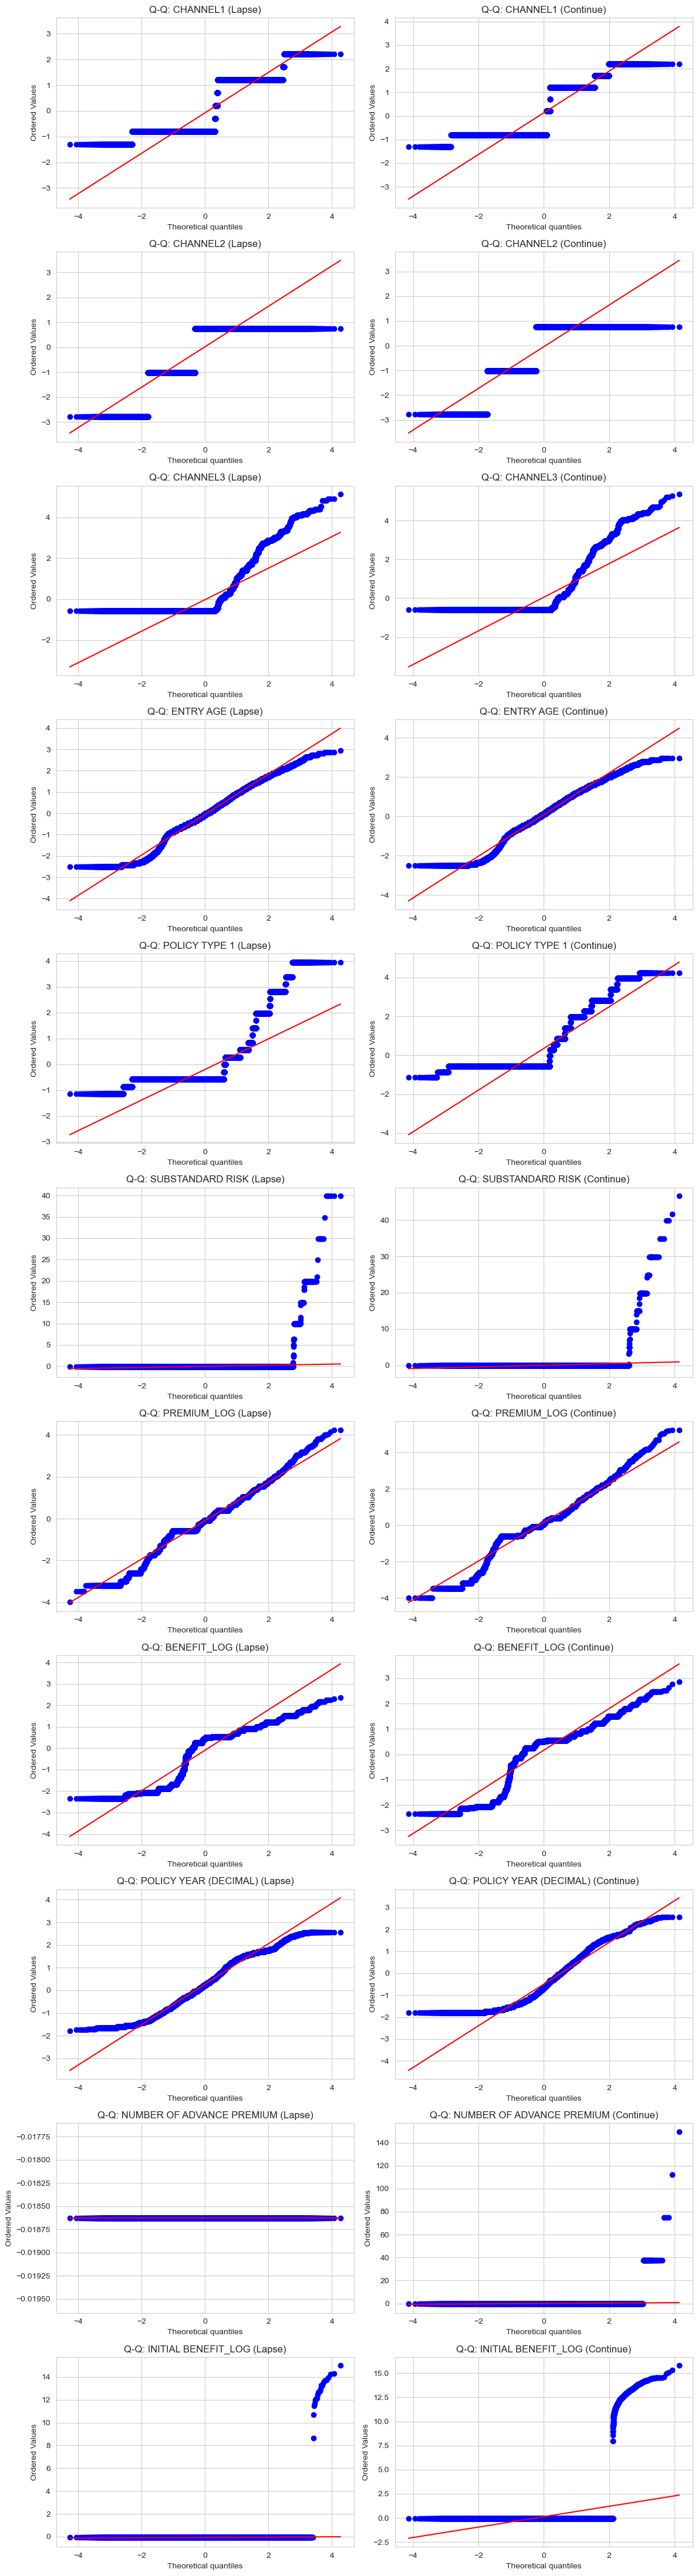

In [50]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

# 1. Define your list of continuous features
# (Assuming current_cont_features is already defined in your environment)
n_features = len(continuous_features)
cols = 2  # We will have 2 columns (Lapse vs Continue) for each feature row
rows = n_features

# 2. Initialize the figure
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))

for i, feature in enumerate(continuous_features):
    # --- Plot for Class 0 (Lapse) ---
    ax_lapse = axes[i, 0]
    stats.probplot(X_train_scaled[y_train == 0][feature], dist="norm", plot=ax_lapse)
    ax_lapse.set_title(f'Q-Q: {feature} (Lapse)')
    ax_lapse.grid(True)
    
    # --- Plot for Class 1 (Continue) ---
    ax_cont = axes[i, 1]
    stats.probplot(X_train_scaled[y_train == 1][feature], dist="norm", plot=ax_cont)
    ax_cont.set_title(f'Q-Q: {feature} (Continue)')
    ax_cont.grid(True)

# 3. Final formatting
plt.tight_layout()
plt.show()

Via the normality assumption check above, we can clearly see that some of the features violate the normality assumption for each class. 

In [ ]:
# Checking homoskedasticity

from scipy.stats import levene

print("Levene’s Test for Equal Variance (p < 0.05 means Variances are DIFFERENT):")
for col in continuous_features:
    stat, p = levene(X_train_scaled[y_train == 0][col], 
                    X_train_scaled[y_train == 1][col])
    print(f"{col:20} | p-value: {p:.4f} | {'Violated (Use QDA)' if p < 0.05 else 'Passed (LDA ok)'}")

Levene’s Test for Equal Variance (p < 0.05 means Variances are DIFFERENT):
CHANNEL1             | p-value: 0.0000 | Violated (Use QDA)
CHANNEL2             | p-value: 0.0000 | Violated (Use QDA)
CHANNEL3             | p-value: 0.0000 | Violated (Use QDA)
ENTRY AGE            | p-value: 0.0000 | Violated (Use QDA)
POLICY TYPE 1        | p-value: 0.0000 | Violated (Use QDA)
SUBSTANDARD RISK     | p-value: 0.0000 | Violated (Use QDA)
PREMIUM_LOG          | p-value: 0.0000 | Violated (Use QDA)
BENEFIT_LOG          | p-value: 0.0000 | Violated (Use QDA)
POLICY YEAR (DECIMAL) | p-value: 0.0000 | Violated (Use QDA)
NUMBER OF ADVANCE PREMIUM | p-value: 0.0000 | Violated (Use QDA)
INITIAL BENEFIT_LOG  | p-value: 0.0000 | Violated (Use QDA)


In order to use LDA, we should ensure the homoskedasticity assumption is fulfilled. However, based on the checking above, homoskedasticity is violated, hence inferring that using QDA might be a better choice.

### Visual Check
QDA works well when the classes are clearly separated. Hence we can conduct a basic visual check. We can use PCA to reduce the dimensions into only 2 components, and plot the datapoints with respect to the both components.

From the result below, clearly we do not have a well-separated classes of CONTINUE vs LAPSE. This raises a question if QDA will work well in separating classes. 

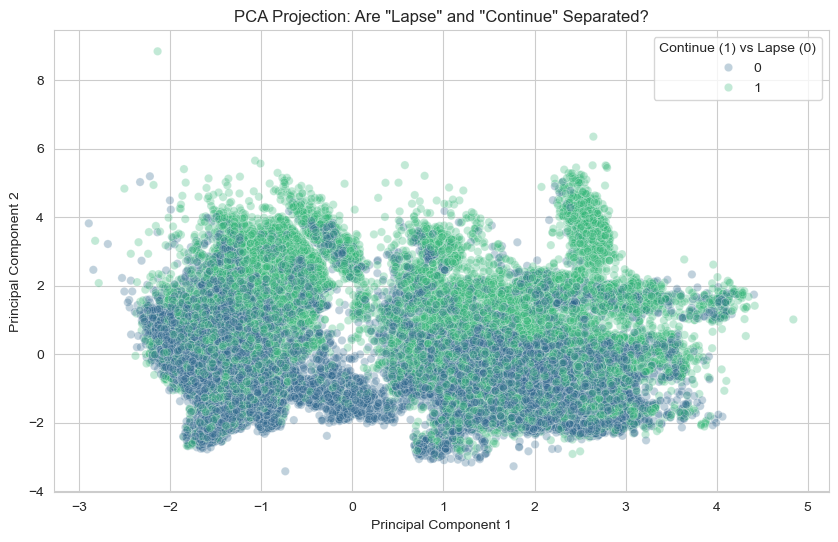

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reduce to 2 Components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Plot the first two PCA components colored by the actual target (CONTINUE)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, alpha=0.3, palette='viridis')
plt.title('PCA Projection: Are "Lapse" and "Continue" Separated?')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Continue (1) vs Lapse (0)')
plt.show()

In [40]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. We'll try 5 clusters since your PCA shows about 4-5 distinct "blobs"
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
X_train_scaled['cluster'] = kmeans.fit_predict(X_train_scaled)

# 2. Check the "Purity" of each cluster
# This tells us: in Cluster X, what percentage actually Continued?
purity_report = pd.DataFrame()
purity_report['Total Count'] = X_train_scaled.groupby('cluster').size()
purity_report['Continue Rate (%)'] = X_train_scaled.groupby('cluster').apply(lambda x: (y_train.loc[x.index] == 1).mean() * 100)

print("--- Cluster Purity Report ---")
print(purity_report)
print("\nIf 'Continue Rate' is near 50% for all clusters, LDA/QDA will perform poorly.")
print("If some clusters are 90% and others are 10%, LDA/QDA has a fighting chance.")

--- Cluster Purity Report ---
         Total Count  Continue Rate (%)
cluster                                
0              36276          26.995810
1              39697          35.899438
2              17405          19.672508
3                 47         100.000000
4              16969          70.864518

If 'Continue Rate' is near 50% for all clusters, LDA/QDA will perform poorly.
If some clusters are 90% and others are 10%, LDA/QDA has a fighting chance.


Cluster purity report is another quantitative metrics showcasing how well-separated the classes are in different clusters. This uses unsupervised learning - K-Means clustering to divide the datasets into separate groups. The point here is that if the unsupervised learning can perform very well, supervised learning such as QDA can perform well too in separating different classes. 

Based on the table above, we can see most most of the data in cluster 3 and 4 is CONTINUE, showing that classification problem might be very accurate and easy within these clusters since most of them belongs to the same class and successfully separated. However, in cluster 0, 1 and 2, there is a mix of classes, both CONTINUE and LAPSE. In a mix class clusters, QDA might not be performing well in separation due to no clear separation.

We will move to the real QDA test to see the actual classification performance. 

In [53]:
# Drop the extra columns
X_train_scaled.drop(columns=['cluster'], inplace=True)

In [54]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 1. INITIALIZE AND FIT QDA
# QDA doesn't have a 'C' or penalty like Lasso; it relies on the quadratic geometry of the classes.
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train_scaled, y_train)

# 2. GENERATE PROBABILITIES
# We use the validation set to find the threshold and the test set for final results
y_prob_val_qda = qda_model.predict_proba(X_val_scaled)[:, 1]
y_prob_test_qda = qda_model.predict_proba(X_test_scaled)[:, 1]

# 3. FIND PRECISION-RECALL EQUILIBRIUM THRESHOLD
# This finds the point where the model is equally good at catching lapses (Recall) 
# and being correct when it says someone will lapse (Precision).
prec_qda, rec_qda, thresholds_qda = precision_recall_curve(y_val, y_prob_val_qda)

# Find index where the difference between Precision and Recall is minimal
idx_qda = np.argmin(np.abs(prec_qda[:-1] - rec_qda[:-1]))
best_t_qda = thresholds_qda[idx_qda]

# 4. FINAL TEST PREDICTION
y_pred_test_qda = (y_prob_test_qda >= best_t_qda).astype(int)

# 5. PERFORMANCE METRICS
print(f"--- QDA FINAL TEST RESULTS ---")
print(f"Optimal Equilibrium Threshold: {best_t_qda:.4f}")
print(f"Misclassification Error Rate:  {1 - accuracy_score(y_test, y_pred_test_qda):.4f}")
print(f"ROC AUC Score:                 {roc_auc_score(y_test, y_prob_test_qda):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_qda))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_qda))

# 6. (OPTIONAL) FEATURE IMPORTANCE HACK
# QDA doesn't have simple .coef_ like Logistic Regression, 
# but we can look at the means of each class to see what drives the separation.
class_means = pd.DataFrame(qda_model.means_, columns=X_train_scaled.columns, index=['Lapse (0)', 'Continue (1)'])
print("\n--- Feature Means by Class (Standardized Units) ---")
print(class_means.T)

--- QDA FINAL TEST RESULTS ---
Optimal Equilibrium Threshold: 0.0000
Misclassification Error Rate:  0.2906
ROC AUC Score:                 0.7438

Confusion Matrix:
[[13810  4053]
 [ 4035  5933]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77     17863
           1       0.59      0.60      0.59      9968

    accuracy                           0.71     27831
   macro avg       0.68      0.68      0.68     27831
weighted avg       0.71      0.71      0.71     27831


--- Feature Means by Class (Standardized Units) ---
                               Lapse (0)  Continue (1)
CHANNEL1                       -0.074276      0.133099
CHANNEL2                        0.022804     -0.040864
CHANNEL3                       -0.027205      0.048751
ENTRY AGE                      -0.055054      0.098655
POLICY TYPE 1                  -0.195137      0.349677
SUBSTANDARD RISK               -0.012112      0.021704
POLICY YEAR (DEC

Based on the result above, our optimal equilibrium threshold is 0.000. This is the cut-off point when our model stopped being biased to any of the classes in prediction. When our model is 0.000, it means that it will assign all observations with probability of CONTINUE >0 to be 1 = continue. This is a sign that QDA is not performing well, because it will assign every class to 1, CONTINUE, instead of LAPSE.

This is supported by the PCA clustering we did previously, where LAPSE and CONTINUE categories are not separated, but overlap very closely to each other. 

## Neural Network

In training the neural network, we used:
1. 22 features, followed by 128 layers (creating 128 different stories on how the predictor variables can interact with each other), 64 layers (as a refinement to only filter important features and signals), 32 layers and then one single binary output (0 or 1)
2. In training the neural network layers in the middle, we used ReLU for this problem because it is a very simple comparison - if the input is negative, then will turn the output into zero, otherwise will just maintain the output. 
3. At the final layer, we use sigmoid function to produce the output because we want a binary output (0 vs 1).

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# 1. DEFINE THE ARCHITECTURE
# Input layer (22 features) -> Hidden (128) -> Hidden (64) -> Hidden (32) -> Output (1)
nn_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

Batch Normalization: ensuring that the inputs to every layer always have a mean of 0 and a standard deviation of 1 (or close to it) for every "batch" of data.

In [33]:
# 2. COMPILE
# Adam is the standard optimizer; Binary Cross-Entropy is your Log-Loss
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                 loss='binary_crossentropy', 
                 metrics=['AUC'])

# 3. EARLY STOPPING
# This stops training if the model stops improving on validation data
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 4. TRAIN (FIT)
print("Training Neural Network...")
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=1024,  # Large batch size for speed with 185k rows
    callbacks=[early_stop],
    verbose=1
)

Training Neural Network...
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.7245 - loss: 0.5725 - val_AUC: 0.7385 - val_loss: 0.5833
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7512 - loss: 0.5421 - val_AUC: 0.7550 - val_loss: 0.5538
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7582 - loss: 0.5346 - val_AUC: 0.7628 - val_loss: 0.5399
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7612 - loss: 0.5311 - val_AUC: 0.7670 - val_loss: 0.5279
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7654 - loss: 0.5261 - val_AUC: 0.7679 - val_loss: 0.5240
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7668 - loss: 0.5240 - val_AUC: 0.7694 - val_loss: 0.5211
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7670 - loss: 0.5227 - val_AUC: 0.7702 - val_loss: 0.5194
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7683 - loss: 0.5204 - val_AUC: 0.7698 - val_loss: 0.5172
Epoch 9/100
108/108 ━

Learning Note:

1. optimizer=tf.keras.optimizers.Adam: Adam stands for Adaptive Moment Estimation.
- It updates the weights of your neurons.
- If the slope is steep, it takes big steps, but if the slope is flat, it slows down to find the exact lowest point.

2. learning_rate=0.001: This is the most important "knob" in the model.
- Too high (e.g., 0.1): The model "jumps" over the optimal solution and never finds it.
- Too low (e.g., 0.00001): The model takes forever to learn and might get stuck in a tiny, suboptimal dip.
- 0.001 is the industry-standard starting point for Adam.

3. loss='binary_crossentropy': This is the mathematical "penalty" for being wrong.
- If a customer actually lapses (1) and the model predicts a 1% chance (0.01), the "penalty" is massive. This forces the model to move its weights until that 1% becomes much higher.
- We then use AUC to decide how does the model performed in comparison to other models

4. monitor='val_loss': It watches the performance on the Validation Set (the data the model isn't studying from).

5. patience=10: This is the model’s "second chance." If the validation performance doesn't improve for 10 rounds in a row, the model assumes it has reached its peak.

6. restore_best_weights=True: Often, at the very end of training, a model starts to "overfit" (memorize noise). This setting tells the computer: "Forget the last 10 bad rounds; go back to the exact moment when we had the best scores and save that version of the model."


In [35]:
# 5. GENERATE PROBABILITIES
y_prob_val_nn = nn_model.predict(X_val_scaled).flatten()
y_prob_test_nn = nn_model.predict(X_test_scaled).flatten()

# 6. FIND PRECISION-RECALL EQUILIBRIUM THRESHOLD
prec_nn, rec_nn, thresholds_nn = precision_recall_curve(y_val, y_prob_val_nn)

# Find index where |Precision - Recall| is minimal
idx_nn = np.argmin(np.abs(prec_nn[:-1] - rec_nn[:-1]))
best_t_nn = thresholds_nn[idx_nn]

# 7. FINAL TEST PREDICTION (Using the Cutoff)
y_pred_test_nn = (y_prob_test_nn >= best_t_nn).astype(int)

# 8. PERFORMANCE METRICS
print(f"\n--- NEURAL NETWORK FINAL TEST RESULTS ---")
print(f"Optimal Equilibrium Threshold: {best_t_nn:.4f}")
print(f"Misclassification Error Rate:  {1 - accuracy_score(y_test, y_pred_test_nn):.4f}")
print(f"ROC AUC Score:                 {roc_auc_score(y_test, y_prob_test_nn):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_nn))

1479/1479 ━━━━━━━━━━━━━━━━━━━━ 1s 358us/step
870/870 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step

--- NEURAL NETWORK FINAL TEST RESULTS ---
Optimal Equilibrium Threshold: 0.3549
Misclassification Error Rate:  0.2654
ROC AUC Score:                 0.7863

Confusion Matrix:
[[14110  3753]
 [ 3633  6335]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79     17863
           1       0.63      0.64      0.63      9968

    accuracy                           0.73     27831
   macro avg       0.71      0.71      0.71     27831
weighted avg       0.74      0.73      0.73     27831



In [53]:
# Using 0.5 threshold
# 7. FINAL TEST PREDICTION (Using the Cutoff)
y_pred_test_nn = (y_prob_test_nn >= 0.51).astype(int)

# 8. PERFORMANCE METRICS
print(f"\n--- NEURAL NETWORK FINAL TEST RESULTS ---")
print(f"Optimal Equilibrium Threshold: {0.51}")
print(f"Misclassification Error Rate:  {1 - accuracy_score(y_test, y_pred_test_nn):.4f}")
print(f"ROC AUC Score:                 {roc_auc_score(y_test, y_prob_test_nn):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test_nn))


--- NEURAL NETWORK FINAL TEST RESULTS ---
Optimal Equilibrium Threshold: 0.51
Misclassification Error Rate:  0.2472
ROC AUC Score:                 0.7863

Confusion Matrix:
[[16556  1307]
 [ 5574  4394]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83     17863
           1       0.77      0.44      0.56      9968

    accuracy                           0.75     27831
   macro avg       0.76      0.68      0.69     27831
weighted avg       0.76      0.75      0.73     27831



In [57]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

def get_nn_feature_importance(model, X_data, y_true, feature_names):
    # --- FIX: Ensure we are working with a NumPy array for slicing ---
    if isinstance(X_data, pd.DataFrame):
        X_arr = X_data.to_numpy()
    else:
        X_arr = np.array(X_data) # Ensure it's a numpy array
        
    # 1. Get the "Base" AUC
    y_pred_base = model.predict(X_arr, verbose=0).flatten()
    base_auc = roc_auc_score(y_true, y_pred_base)
    
    importance_dict = {}
    print(f"Base AUC: {base_auc:.4f}")

    # 2. Iterate through each feature by index
    for i, col in enumerate(feature_names):
        # Create a fresh copy of the array
        X_permuted = X_arr.copy()
        
        # Scramble just THIS one column (column index i)
        # np.random.permutation shuffles the values in that column
        X_permuted[:, i] = np.random.permutation(X_permuted[:, i])
        
        # Get new predictions and new AUC
        y_pred_permuted = model.predict(X_permuted, verbose=0).flatten()
        permuted_auc = roc_auc_score(y_true, y_pred_permuted)
        
        # Importance = how much the AUC dropped
        importance = base_auc - permuted_auc
        importance_dict[col] = importance
        print(f"Done: {col}") # Progress check

    # 3. Sort and Return
    return pd.Series(importance_dict).sort_values(ascending=False)

# --- RUN IT ---
# We pass the original column names from X_test so the labels look nice
nn_importances = get_nn_feature_importance(nn_model, X_test_scaled, y_test, X_test.columns)

print("\n--- NEURAL NETWORK FEATURE IMPORTANCE ---")
print(nn_importances)

Base AUC: 0.7863
Done: CHANNEL1
Done: CHANNEL2
Done: CHANNEL3
Done: ENTRY AGE
Done: POLICY TYPE 1
Done: SUBSTANDARD RISK
Done: PREMIUM
Done: BENEFIT
Done: POLICY YEAR (DECIMAL)
Done: NUMBER OF ADVANCE PREMIUM
Done: INITIAL BENEFIT
Done: SEX_M
Done: PAYMENT MODE_Monthly
Done: PAYMENT MODE_Quaterly
Done: PAYMENT MODE_Semiannually
Done: PAYMENT MODE_Single Premium
Done: POLICY TYPE 3_B
Done: POLICY TYPE 3_C
Done: POLICY TYPE 3_D
Done: POLICY TYPE 3_E
Done: FULL BENEFIT?_Y
Done: NON LAPSE GUARANTEED_Inactive

--- NEURAL NETWORK FEATURE IMPORTANCE ---
PREMIUM                          0.114537
NUMBER OF ADVANCE PREMIUM        0.042003
CHANNEL1                         0.026327
FULL BENEFIT?_Y                  0.024518
POLICY TYPE 1                    0.019055
POLICY TYPE 3_B                  0.012430
CHANNEL2                         0.012188
ENTRY AGE                        0.010837
POLICY TYPE 3_E                  0.009297
INITIAL BENEFIT                  0.008409
CHANNEL3                   